In [ ]:
# Install required packages
!pip install scikit-learn

# Additional installations
!pip install datasets

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import os
import numpy as np

In [ ]:
from time import time
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB, ComplementNB
from sklearn import metrics
import pandas as pd
import xml.etree.ElementTree as ET
import copy
import numpy as np
import pandas as pd
import os
from sklearn import preprocessing
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
#data = import_hands(0, 1, 'right', toDataFrame=True)

#hands_syllables = pd.read_pickle('/content/hands_syllables')
#preprocess_hands = pd.read_pickle('/content/hands_preprocessed_syllables')
#umap_values = extract_values(preprocess_hands, as_array=False)

features = pd.read_pickle('/content/drive/MyDrive/ThisPC/DesignMotorTask/hands_features')

section_list = ['LFUp', 'LMUp', 'LBUp', 'LFDown', 'LMDown', 'LBDown',
                'RFUp', 'RMUp', 'RBUp', 'RFDown', 'RMDown', 'RBDown',
                'CFUp', 'CMUp', 'CBUp', 'CFDown', 'CMDown', 'CBDown',
                'CLFUp', 'CRFUp', 'CLFDown', 'CRFDown']


In [ ]:
features

5. Applying Naive Bayes

**6. Calculating accuracy and generating classification report from test data**

In [ ]:
def NB_(features, level, hand,  test_size=0.2, plot=True, up_vs_down=False):

  print(f'Level: {level} \nHand: {hand}')

  # build naive bayes classification model
  t = time()

  #naive_bayes_classifier = GaussianNB()
  #naive_bayes_classifier = MultinomialNB()
  naive_bayes_classifier = ComplementNB()

  if level == 1:
    X = features.loc[:,['CFDown', 'CFUp'],:, :, level,:,hand]
    y = X.index.get_level_values('syllable')
  if level == 2:
    X = features.loc[:,['LFDown', 'LFUp', 'RFDown', 'RFUp'],:,:,level,:,hand]
    y = X.index.get_level_values('syllable')
  if level == 'all':
    X = features.loc[:,['CFDown', 'CFUp',
                                      'LFDown', 'LFUp', 'RFDown', 'RFUp'],:,:,:,:,hand]
    y = X.index.get_level_values('syllable')


  if up_vs_down:
    y = np.where(y.str.endswith('Up'), 'Up', 'Down')

  X_train, X_test, y_train, y_test = train_test_split(X.values, y, test_size=test_size)

  # Initialize random under-sampler to balance the classes in training data
  runs = RandomUnderSampler(random_state=42)
  X_train, y_train = runs.fit_resample(X_train, y_train)


  # ---------------------------------------------------------------

  labels, counts = np.unique(y_train, return_counts=True)
  nr_train_samples = dict(zip(labels, counts))
  labels, counts = np.unique(y_test, return_counts=True)
  nr_test_samples = dict(zip(labels, counts))
  print(f'train samples: {len(X_train)} {nr_train_samples}\ntest samples: {len(X_test)} {nr_test_samples}')

  naive_bayes_classifier.fit(X_train, y_train)

  training_time = time() - t
  print("train time: %0.3fs" % training_time)

  # predict the new document from the testing dataset
  t = time()
  pred_labels = naive_bayes_classifier.predict(X_test)

  val_time = time() - t
  print("test time:  %0.3fs" % val_time)

  # compute the performance measures
  score1 = metrics.accuracy_score(y_test, pred_labels)
  print("accuracy:   %0.3f" % score1)
  print(metrics.classification_report(y_test, pred_labels))
  print("confusion matrix:")
  cm = metrics.confusion_matrix(y_test, pred_labels)
  print(metrics.confusion_matrix(y_test, pred_labels))

  print('------------------------------')


  if plot:

    # Plot confusion matrix
    plt.figure(figsize=(6, 4.7))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


Level: 1 
Hand: Right
train samples: 64 {'CFDown': 32, 'CFUp': 32}
test samples: 42 {'CFDown': 34, 'CFUp': 8}
train time: 0.041s
test time:  0.001s
accuracy:   0.905
              precision    recall  f1-score   support

      CFDown       0.94      0.94      0.94        34
        CFUp       0.75      0.75      0.75         8

    accuracy                           0.90        42
   macro avg       0.85      0.85      0.85        42
weighted avg       0.90      0.90      0.90        42

confusion matrix:
[[32  2]
 [ 2  6]]
------------------------------


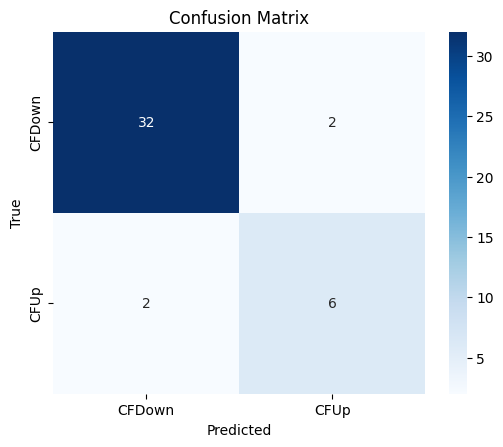

In [ ]:
NB_(features.iloc[:, :-100], 1, 'Right')

Level: 2 
Hand: Right
train samples: 268 {'LFDown': 67, 'LFUp': 67, 'RFDown': 67, 'RFUp': 67}
test samples: 139 {'LFDown': 33, 'LFUp': 15, 'RFDown': 65, 'RFUp': 26}
train time: 0.255s
test time:  0.008s
accuracy:   0.633
              precision    recall  f1-score   support

      LFDown       0.49      0.55      0.51        33
        LFUp       0.43      0.80      0.56        15
      RFDown       0.77      0.71      0.74        65
        RFUp       0.86      0.46      0.60        26

    accuracy                           0.63       139
   macro avg       0.63      0.63      0.60       139
weighted avg       0.68      0.63      0.64       139

confusion matrix:
[[18  4 10  1]
 [ 1 12  2  0]
 [16  2 46  1]
 [ 2 10  2 12]]
------------------------------


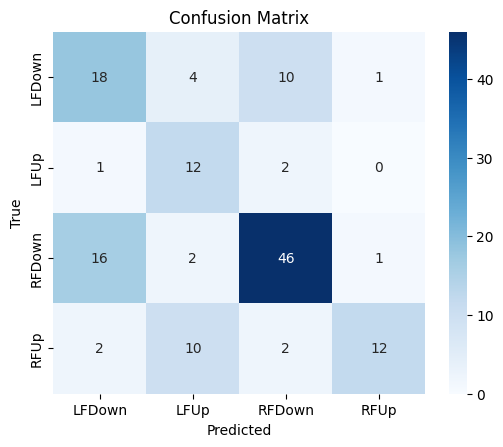

In [ ]:
NB_(features.iloc[:, :-100], 2, 'Right')

Level: all 
Hand: Right
train samples: 450 {'CFDown': 75, 'CFUp': 75, 'LFDown': 75, 'LFUp': 75, 'RFDown': 75, 'RFUp': 75}
test samples: 257 {'CFDown': 43, 'CFUp': 24, 'LFDown': 52, 'LFUp': 27, 'RFDown': 72, 'RFUp': 39}
train time: 0.365s
test time:  0.010s
accuracy:   0.490
              precision    recall  f1-score   support

      CFDown       0.41      0.28      0.33        43
        CFUp       0.29      0.25      0.27        24
      LFDown       0.52      0.54      0.53        52
        LFUp       0.45      0.63      0.52        27
      RFDown       0.55      0.65      0.59        72
        RFUp       0.55      0.41      0.47        39

    accuracy                           0.49       257
   macro avg       0.46      0.46      0.45       257
weighted avg       0.48      0.49      0.48       257

confusion matrix:
[[12  0 14  0 17  0]
 [ 1  6  1  6  4  6]
 [ 7  1 28  4 11  1]
 [ 0  2  0 17  3  5]
 [ 9  4  9  2 47  1]
 [ 0  8  2  9  4 16]]
------------------------------


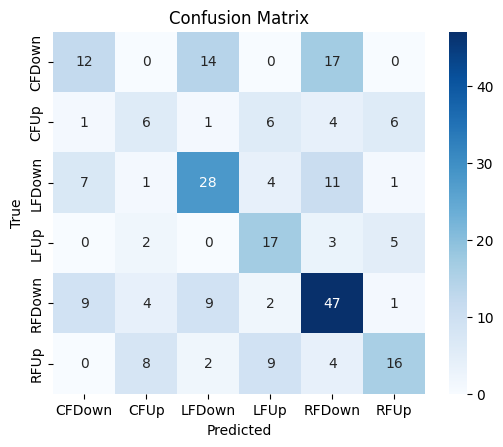

In [ ]:
NB_(features.iloc[:, :-100], 'all', 'Right')

Level: 1 
Hand: Left
train samples: 46 {'CFDown': 23, 'CFUp': 23}
test samples: 26 {'CFDown': 18, 'CFUp': 8}
train time: 0.030s
test time:  0.001s
accuracy:   0.808
              precision    recall  f1-score   support

      CFDown       0.88      0.83      0.86        18
        CFUp       0.67      0.75      0.71         8

    accuracy                           0.81        26
   macro avg       0.77      0.79      0.78        26
weighted avg       0.82      0.81      0.81        26

confusion matrix:
[[15  3]
 [ 2  6]]
------------------------------


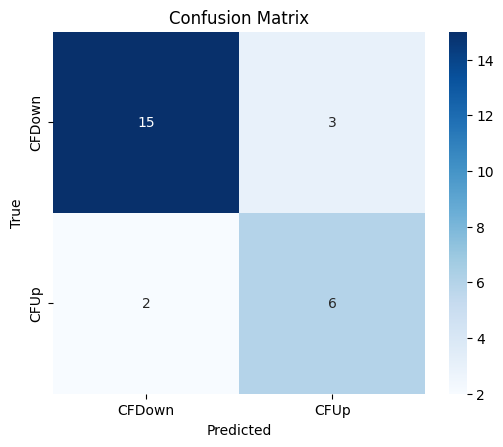

In [ ]:
NB_(features.iloc[:, :-100], 1, 'Left')

Level: 2 
Hand: Left
train samples: 232 {'LFDown': 58, 'LFUp': 58, 'RFDown': 58, 'RFUp': 58}
test samples: 138 {'LFDown': 62, 'LFUp': 33, 'RFDown': 29, 'RFUp': 14}
train time: 0.246s
test time:  0.010s
accuracy:   0.688
              precision    recall  f1-score   support

      LFDown       0.75      0.79      0.77        62
        LFUp       0.78      0.64      0.70        33
      RFDown       0.67      0.48      0.56        29
        RFUp       0.44      0.79      0.56        14

    accuracy                           0.69       138
   macro avg       0.66      0.67      0.65       138
weighted avg       0.71      0.69      0.69       138

confusion matrix:
[[49  4  6  3]
 [ 5 21  0  7]
 [11  0 14  4]
 [ 0  2  1 11]]
------------------------------


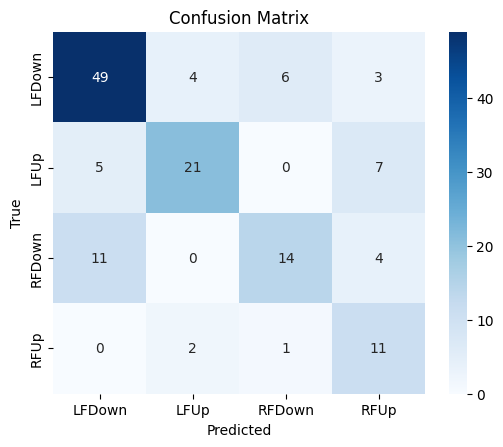

In [ ]:
NB_(features.iloc[:, :-100], 2, 'Left')

Level: all 
Hand: Left
train samples: 378 {'CFDown': 63, 'CFUp': 63, 'LFDown': 63, 'LFUp': 63, 'RFDown': 63, 'RFUp': 63}
test samples: 232 {'CFDown': 34, 'CFUp': 16, 'LFDown': 98, 'LFUp': 53, 'RFDown': 16, 'RFUp': 15}
train time: 0.260s
test time:  0.010s
accuracy:   0.517
              precision    recall  f1-score   support

      CFDown       0.00      0.00      0.00        34
        CFUp       0.15      0.31      0.20        16
      LFDown       0.77      0.74      0.76        98
        LFUp       0.68      0.43      0.53        53
      RFDown       0.28      0.69      0.39        16
        RFUp       0.29      0.53      0.37        15

    accuracy                           0.52       232
   macro avg       0.36      0.45      0.38       232
weighted avg       0.53      0.52      0.51       232

confusion matrix:
[[ 0  5 14  0 13  2]
 [ 1  5  2  5  0  3]
 [ 0  7 73  4 12  2]
 [ 0 12  1 23  4 13]
 [ 0  0  5  0 11  0]
 [ 0  5  0  2  0  8]]
------------------------------


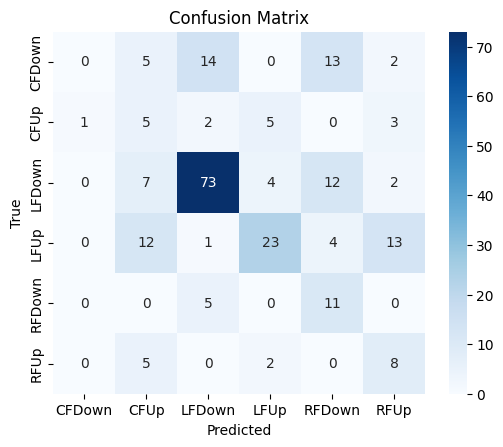

In [ ]:
NB_(features.iloc[:, :-100], 'all', 'Left')

Level: all 
Hand: Right
train samples: 702 {'Down': 351, 'Up': 351}
test samples: 257 {'Down': 174, 'Up': 83}
train time: 0.223s
test time:  0.005s
accuracy:   0.844
              precision    recall  f1-score   support

        Down       0.89      0.87      0.88       174
          Up       0.75      0.78      0.76        83

    accuracy                           0.84       257
   macro avg       0.82      0.83      0.82       257
weighted avg       0.85      0.84      0.85       257

confusion matrix:
[[152  22]
 [ 18  65]]
------------------------------


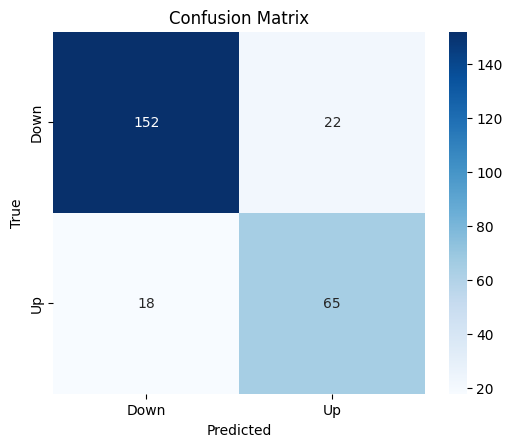

In [ ]:
NB_(features.iloc[:, :-100], 'all', 'Right', up_vs_down=True)

Level: all 
Hand: Left
train samples: 692 {'Down': 346, 'Up': 346}
test samples: 232 {'Down': 140, 'Up': 92}
train time: 0.206s
test time:  0.005s
accuracy:   0.853
              precision    recall  f1-score   support

        Down       0.88      0.87      0.88       140
          Up       0.81      0.83      0.82        92

    accuracy                           0.85       232
   macro avg       0.85      0.85      0.85       232
weighted avg       0.85      0.85      0.85       232

confusion matrix:
[[122  18]
 [ 16  76]]
------------------------------


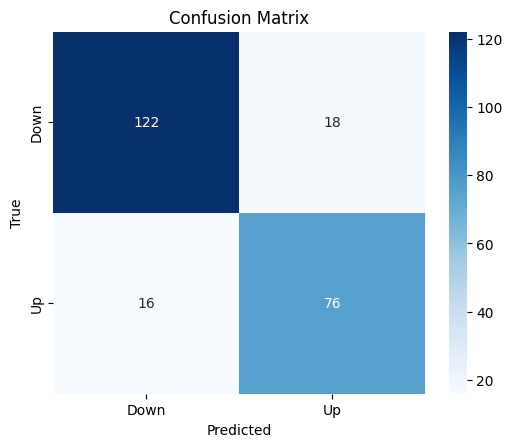

In [ ]:
NB_(features.iloc[:, :-100], 'all', 'Left', up_vs_down=True)

Level: all 
Hand: Right
train samples: 698 {'Down': 349, 'Up': 349}
test samples: 257 {'Down': 172, 'Up': 85}
train time: 0.009s
test time:  0.001s
accuracy:   0.654
              precision    recall  f1-score   support

        Down       0.76      0.71      0.73       172
          Up       0.48      0.54      0.51        85

    accuracy                           0.65       257
   macro avg       0.62      0.63      0.62       257
weighted avg       0.67      0.65      0.66       257

confusion matrix:
[[122  50]
 [ 39  46]]
------------------------------


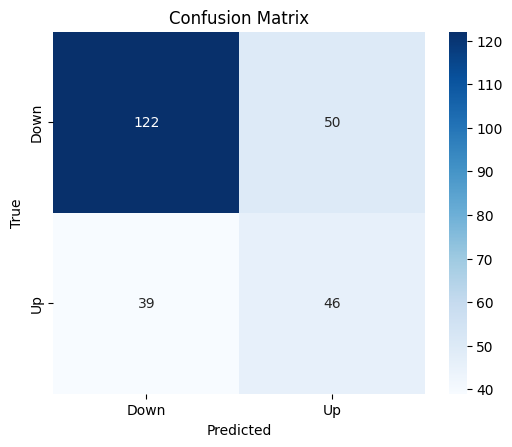

In [ ]:
# up vs. down just the palm direction:

NB_(features.iloc[:, 200:300], 'all', 'Right', up_vs_down=True)

Level: all 
Hand: Left
train samples: 700 {'Down': 350, 'Up': 350}
test samples: 232 {'Down': 144, 'Up': 88}
train time: 0.011s
test time:  0.000s
accuracy:   0.651
              precision    recall  f1-score   support

        Down       0.73      0.70      0.71       144
          Up       0.54      0.57      0.55        88

    accuracy                           0.65       232
   macro avg       0.63      0.63      0.63       232
weighted avg       0.65      0.65      0.65       232

confusion matrix:
[[101  43]
 [ 38  50]]
------------------------------


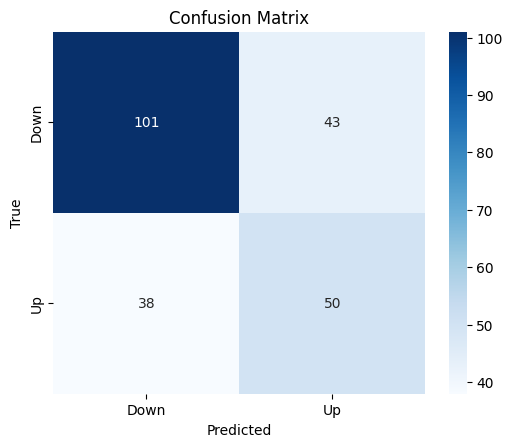

In [ ]:
NB_(features.iloc[:, 200:300], 'all', 'Left', up_vs_down=True)

Level: all 
Hand: Right
train samples: 698 {'Down': 349, 'Up': 349}
test samples: 257 {'Down': 172, 'Up': 85}
train time: 0.018s
test time:  0.000s
accuracy:   0.665
              precision    recall  f1-score   support

        Down       0.67      0.99      0.80       172
          Up       0.33      0.01      0.02        85

    accuracy                           0.67       257
   macro avg       0.50      0.50      0.41       257
weighted avg       0.56      0.67      0.54       257

confusion matrix:
[[170   2]
 [ 84   1]]
------------------------------


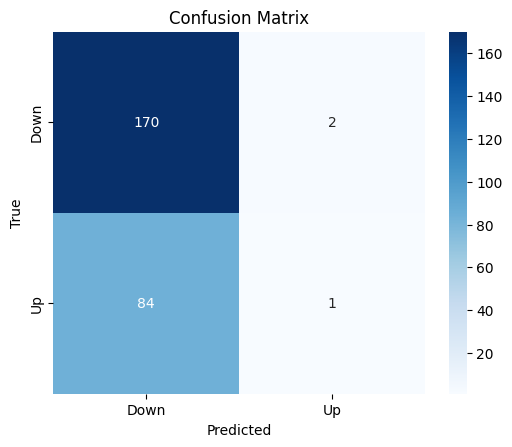

In [ ]:
# random (just timestamps normalized):
NB_(features.iloc[:, -100:], 'all', 'Right', up_vs_down=True)

Level: all 
Hand: Left
train samples: 686 {'Down': 343, 'Up': 343}
test samples: 232 {'Down': 137, 'Up': 95}
train time: 0.014s
test time:  0.000s
accuracy:   0.591
              precision    recall  f1-score   support

        Down       0.60      0.96      0.73       137
          Up       0.50      0.06      0.11        95

    accuracy                           0.59       232
   macro avg       0.55      0.51      0.42       232
weighted avg       0.56      0.59      0.48       232

confusion matrix:
[[131   6]
 [ 89   6]]
------------------------------


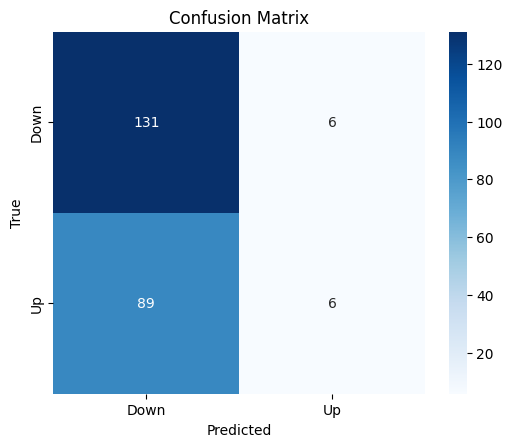

In [ ]:
NB_(features.iloc[:, -100:], 'all', 'Left', up_vs_down=True)

In [ ]:

  def label_to_int(y):

    label_encoder = LabelEncoder()
    new_y = label_encoder.fit_transform(y)

    return y, new_y

  # ---------------------------------------------------------------


  #str_y_train, y_train = label_to_int(y_train)
  #str_y_test, y_test = label_to_int(y_test)

  # Identify the class with the minimum number of samples
  #min_samples = min(np.bincount(y_train))

  # Resample each class to have the same number of samples
  #X_train_balanced = np.concatenate([resample(X_train[y_train == i], n_samples=min_samples, replace=True, random_state=42) for i in np.unique(y_train)])
  #y_train_balanced = np.concatenate([np.full(min_samples, i) for i in np.unique(y_train)])

  #X_test_balanced = np.concatenate([resample(X_train[y_train == i], n_samples=min_samples, replace=True, random_state=42) for i in np.unique(y_train)])
  #y_test_balanced = np.concatenate([np.full(min_samples, i) for i in np.unique(y_train)])


  #print(y_train_balanced)

  # Shuffle the balanced data
  #shuffle_indices = np.arange(len(X_train_balanced))
  #X_train = X_train_balanced[shuffle_indices]
  #y_train = y_train_balanced[shuffle_indices]


  # ---------------------------------------------------------------
